### ADD THIS IN THE LATEX DATA UNDERSTANDING / PREPARATION, ignore for this notebook

Also, comment that exactly 33% of the values in the whole original dataset are missing. 

In [ ]:
df = pd.read_csv('../dataset/cmi_internet.csv')
df

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.50,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,Spring,7,1,Spring,NaN,Fall,16.130585,46.07,49.0,...,NaN,NaN,NaN,NaN,Summer,38.5,55.0,Spring,0.0,0.0
8456,8456,Winter,10,1,Spring,69.5,Winter,NaN,56.13,47.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Winter,0.0,1.0
8457,8457,Winter,10,1,Winter,70.0,Winter,40.937571,49.56,47.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,2.0,0.0
8458,8458,Fall,15,1,NaN,55.5,Spring,NaN,63.79,99.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,1.0,2.0


In [6]:
# Discretize the "PCIAT-PCIAT_Total" column into a "sii2" column using: 0-30->0; 31-49->1; 50-79->2; 80-100->3;
# then compare row by row with the values in "sii" column: 
cond = [
    df['PCIAT-PCIAT_Total'].between(0, 30, inclusive='both'),
    df['PCIAT-PCIAT_Total'].between(31, 49, inclusive='both'),
    df['PCIAT-PCIAT_Total'].between(50, 79, inclusive='both'),
    df['PCIAT-PCIAT_Total'].between(80, 100, inclusive='both'),
]
choices = [0, 1, 2, 3]

df['sii2'] = np.select(cond, choices, default=np.nan)
df['sii_match'] = (df['sii2'] == df['sii']) | (df['sii2'].isna() & df['sii'].isna())

print("Matches:", int(df['sii_match'].sum()), "out of", len(df))
print("Mismatch count:", int((~df['sii_match']).sum()))

df[['PCIAT-PCIAT_Total', 'sii2', 'sii', 'sii_match']]

Matches: 2708 out of 8460
Mismatch count: 5752


,PCIAT-PCIAT_Total,sii2,sii,sii_match
0,55.0,2.0,2.0,True
1,0.0,0.0,0.0,True
2,28.0,0.0,0.0,True
3,44.0,1.0,1.0,True
4,NaN,NaN,0.0,False
...,...,...,...,...
8455,NaN,NaN,0.0,False
8456,NaN,NaN,1.0,False
8457,NaN,NaN,0.0,False
8458,NaN,NaN,2.0,False


In [7]:
# Do it but removing all rows with missing values in "PCIAT" before
df = df.dropna(subset=['PCIAT-PCIAT_Total']).copy()

cond = [
    df['PCIAT-PCIAT_Total'].between(0, 30, inclusive='both'),
    df['PCIAT-PCIAT_Total'].between(31, 49, inclusive='both'),
    df['PCIAT-PCIAT_Total'].between(50, 79, inclusive='both'),
    df['PCIAT-PCIAT_Total'].between(80, 100, inclusive='both'),
]
choices = [0, 1, 2, 3]

df['sii2'] = np.select(cond, choices, default=np.nan)
df['sii_match'] = (df['sii2'] == df['sii']) | (df['sii2'].isna() & df['sii'].isna())

print("Rows after dropping missing PCIAT-PCIAT_Total:", len(df))
print("Matches:", int(df['sii_match'].sum()), "out of", len(df))
print("Mismatch count:", int((~df['sii_match']).sum()))

df[['PCIAT-PCIAT_Total', 'sii2', 'sii', 'sii_match']].head()

Rows after dropping missing PCIAT-PCIAT_Total: 2714
Matches: 2708 out of 2714
Mismatch count: 6


,PCIAT-PCIAT_Total,sii2,sii,sii_match
0,55.0,2.0,2.0,True
1,0.0,0.0,0.0,True
2,28.0,0.0,0.0,True
3,44.0,1.0,1.0,True
5,34.0,1.0,1.0,True


In [8]:
# Print the 6 missmatches of the previous table
mismatches = df[~df['sii_match']][['PCIAT-PCIAT_Total', 'sii2', 'sii']]
print(mismatches)

      PCIAT-PCIAT_Total  sii2  sii
4835               32.0   1.0  0.0
5525               43.0   1.0  0.0
5566               27.0   0.0  1.0
6379               60.0   2.0  3.0
7152               40.0   1.0  2.0
8267               26.0   0.0  1.0


# Imbalanced Learning

Guidelines: Define one simple unbalanced classification tasks and solve it either with a Decision Tree or KNN by adopting at least 2 techniques of imbalanced learning (Undersampling, Oversampling). If the dataset is already unbalanced, leave it as it is; otherwise, modify it to create an imbalanced version (e.g., 96% - 4%, for binary classification).

Does "simple" mean "binary"?? No, using simple models

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.preprocessing import StandardScaler

In [ ]:
#df = pd.read_csv('cmi_internet_cleaned.csv') # Leo&Lore leave this line commented, don't delete it, thanks
df = pd.read_csv('../dataset/cmi_internet_cleaned.csv')
df

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii
0,5.0,0.0,51,46.000000,50.8,26.000000,69,5,87,114,...,1,24.434900,8.895360,38.917700,19.541300,2.12927,60,3,448,2
1,9.0,0.0,66,48.000000,46.0,22.000000,75,5,70,122,...,1,21.035200,14.974000,39.449700,15.410700,2.01000,64,0,434,0
2,10.0,1.0,71,56.500000,75.6,26.003679,65,5,94,117,...,2,30.424101,32.959842,56.996400,33.418724,2.17000,54,2,453,0
3,9.0,0.0,71,56.000000,81.6,26.000000,60,6,97,117,...,2,30.404100,16.779000,58.933800,26.479800,2.45100,45,0,577,1
4,18.0,1.0,65,62.206792,77.0,26.000000,68,5,80,116,...,2,28.855800,23.975607,56.996400,33.915114,1.04000,58,1,433,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7834,7.0,1.0,69,46.070000,49.0,22.250000,58,2,82,103,...,1,21.134424,12.375831,37.154343,16.637908,3.00000,55,0,510,0
7835,10.0,1.0,70,56.130000,47.8,28.500000,66,5,80,108,...,1,22.690881,16.569017,48.610678,22.983200,2.00000,57,0,452,1
7836,10.0,1.0,70,49.560000,47.2,25.341680,64,7,84,120,...,2,30.581230,32.655921,50.805915,31.594712,2.00000,57,2,528,0
7837,15.0,1.0,56,63.790000,99.5,31.100000,67,5,88,108,...,2,30.387635,25.248149,84.622873,46.467581,2.00000,59,1,478,2


## Data Preparation

In [125]:
X = df.drop(columns=['sii'])
y = df['sii'].astype(int)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Variables used:")
print(num_cols)
print("Shape:", X.shape)

Variables used:
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time']
Shape: (7839, 32)


In [126]:
scaler = StandardScaler() # very important for KNN

X = scaler.fit_transform(X)

X = pd.DataFrame(
    X,
    columns=num_cols,
    index=df.index
)

X

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
0,-1.455578,-0.831202,-1.742234,-1.552922,-0.875197,-0.234492,0.038753,0.156041,0.482376,-0.084153,...,-0.660052,-1.384469,-0.612161,-1.260839,-1.077678,-0.802498,-0.174214,0.231901,2.046019,0.102626
1,-0.303665,-0.831202,0.015577,-1.264123,-1.013495,-1.576783,0.648147,0.156041,-1.143063,0.557944,...,-0.982432,-1.384469,-1.021174,-0.569694,-1.051730,-1.096239,-0.410924,0.665373,-0.956366,-0.070741
2,-0.015687,1.203077,0.601514,-0.036727,-0.160659,-0.233257,-0.367510,0.156041,1.151674,0.156634,...,-0.232040,0.500361,0.108390,1.475307,-0.195909,0.184373,-0.093381,-0.418307,1.045224,0.164542
3,-0.303665,-0.831202,0.601514,-0.108927,0.012213,-0.234492,-0.875338,1.479854,1.438516,0.156634,...,-0.069114,0.500361,0.105984,-0.364464,-0.101415,-0.309077,0.464304,-1.393619,-0.956366,1.700076
4,2.288140,1.203077,-0.101610,0.787330,-0.120322,-0.234492,-0.062813,0.156041,-0.186922,0.076371,...,-0.232040,0.500361,-0.080290,0.453794,-0.195909,0.219673,-2.336027,0.015165,0.044429,-0.083124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7834,-0.879622,1.203077,0.367139,-1.542814,-0.927059,-1.492890,-1.078470,-3.815399,0.004306,-0.967037,...,-1.031431,-1.384469,-1.009236,-0.865107,-1.163684,-1.008968,1.553872,-0.309939,-0.956366,0.870393
7835,-0.015687,1.203077,0.484327,-0.090155,-0.961633,0.604440,-0.265944,0.156041,-0.186922,-0.565726,...,-0.756132,-1.384469,-0.821981,-0.388340,-0.604914,-0.557733,-0.430770,-0.093203,-0.956366,0.152159
7836,-0.015687,1.203077,0.484327,-1.038860,-0.978921,-0.455406,-0.469076,2.803667,0.195534,0.397420,...,-1.226594,0.500361,0.127294,1.440751,-0.497843,0.054662,-0.430770,-0.093203,1.045224,1.093293
7837,1.424205,1.203077,-1.156297,1.015945,0.527948,1.476929,-0.164379,0.156041,0.577990,-0.565726,...,0.416299,0.500361,0.104003,0.598483,1.151542,1.112322,-0.430770,0.123533,0.044429,0.474126


In [127]:
# The four classes of sii are imbalanced:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3]), array([5476, 1444,  846,   73]))

In [128]:
# Alternatively
ctr = Counter(y)
ctr

Counter({0: 5476, 1: 1444, 2: 846, 3: 73})

In [184]:
5476/(5476+1444+846+73), 73/(5476+1444+846+73)

(0.6985584896032657, 0.009312412297486925)

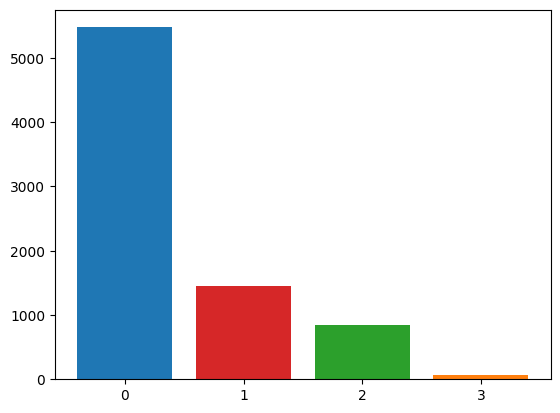

In [129]:
plt.bar(ctr.keys(), ctr.values(), color=['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])
plt.xticks(list(ctr.keys()))
plt.show()

### Previous trials, ignore

In [35]:
print(5833+1587)
print(952+88)
print(7420/(7420+1040))

7420
1040
0.8770685579196218


I have decided that we will turn it into a binary classification problem with imbalanced classes,
by grouping the classes 0 (None) and 1 (Mild) into a single one ('Low Impairement');
and the classes 2 (Moderate) and 3 (Severe) into another ('High Impairement'):

In [6]:
y2 = y.copy()
y2[y2 <= 1] = 0
y2[y2 > 1] = 1 
y2

0       1
1       0
2       0
3       0
4       0
       ..
8455    0
8456    0
8457    0
8458    1
8459    0
Name: sii, Length: 8460, dtype: int64

In [7]:
ctr = Counter(y2)
ctr

Counter({0: 7420, 1: 1040})

Let's check if we could do simple classification using other variables.

Possible categorical candidates are: Sex (not interesting), BIA-BIA_Frame_num (Body Frame: Small, Medium, Large; unbalanced), PreInt_EduHx-computerinternet_hoursday (0,1,2,3; less unbalanced).

Maybe the best option of these is Body Frame (should we turn it binary?), although I like the sii version better.

## Data Partitioning

In [ ]:
from sklearn.model_selection import train_test_split

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [131]:
# Records of each class in train and test datasets keep the proportion of the original dataset thanks to 'stratify':
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1, 2, 3]), array([3833, 1011,  592,   51])),
 (array([0, 1, 2, 3]), array([1643,  433,  254,   22])))

In [132]:
# Percentage of the majority class in the training/test set:
np.max(np.unique(y_train, return_counts=True)[1])/len(y_train) * 100

69.85602332786587

In [133]:
# Percentage of the minority class in the training/test set:
np.min(np.unique(y_train, return_counts=True)[1])/len(y_train) * 100

0.9294696555494806

## Classification

In [10]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [ ]:
#import sys
#import subprocess
#import importlib.util

#package = 'scikit-plot'
#spec = importlib.util.find_spec('scikitplot')
#if spec is None:
#    print(f'Installing {package}...')
#    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'scikit-plot==0.3.7'])
#else:
#    print(f'{package} already installed.')

#try:
#    import scikitplot
#    print('scikitplot version', scikitplot.__version__)
#except Exception as exc:
#    print('Error importing scikitplot:', exc)

scikit-plot already installed.
Error importing scikitplot: cannot import name 'interp' from 'scipy' (/Users/elia/Desktop/Master/.venv/lib/python3.11/site-packages/scipy/__init__.py)


In [1]:
#try:
#    from scikitplot.metrics import plot_roc
#except Exception:
#    import sys, subprocess, importlib
#    import numpy as np
#    try:
#        import scipy
#        scipy.interp = np.interp
#    except Exception:
#        pass
#    print('Installing or repairing scikit-plot and retrying import...')
#    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'scikit-plot==0.3.7'])
#    importlib.invalidate_caches()
#    from scikitplot.metrics import plot_roc
# scikitplot will be installed/patched by the above block if needed

Installing or repairing scikit-plot and retrying import...


In [11]:
from sklearn.dummy import DummyClassifier

In [134]:
clf = DummyClassifier() # classifies everything as the majority class (class 0 in this case)
clf.fit(X_train, y_train)

y_pred0 = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred0))
print('F1-score %s' % f1_score(y_test, y_pred0, average=None))
print(classification_report(y_test, y_pred0))

Accuracy 0.6985544217687075
F1-score [0.82252816 0.         0.         0.        ]
              precision    recall  f1-score   support

           0       0.70      1.00      0.82      1643
           1       0.00      0.00      0.00       433
           2       0.00      0.00      0.00       254
           3       0.00      0.00      0.00        22

    accuracy                           0.70      2352
   macro avg       0.17      0.25      0.21      2352
weighted avg       0.49      0.70      0.57      2352



#### Previous attempts of ROC curve plot with sklearn

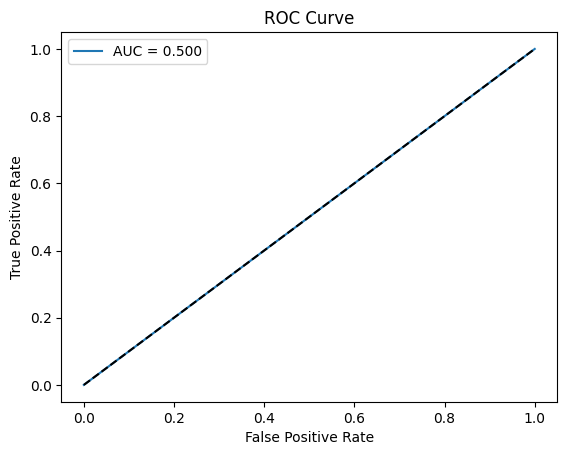

In [ ]:
# IGNORE CELL

y_score = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# IGNORE CELL
 
from sklearn.preprocessing import label_binarize

# get the probability estimates for each class
y_score_proba = clf.predict_proba(X_test)

# binarize the true labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))
plt.plot(fpr[0], tpr[0], label=f'ROC class 0 (AUC = {roc_auc[0]:.3f})', lw=2)
plt.plot(fpr[1], tpr[1], label=f'ROC class 1 (AUC = {roc_auc[1]:.3f})', lw=2)
plt.plot(fpr["micro"], tpr["micro"], label=f'micro-average (AUC = {roc_auc["micro"]:.3f})', linestyle=':', lw=2)
plt.plot(fpr["macro"], tpr["macro"], label=f'macro-average (AUC = {roc_auc["macro"]:.3f})', linestyle='--', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: class-wise, micro-average, macro-average')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [2538, 5076]

#### Moving on

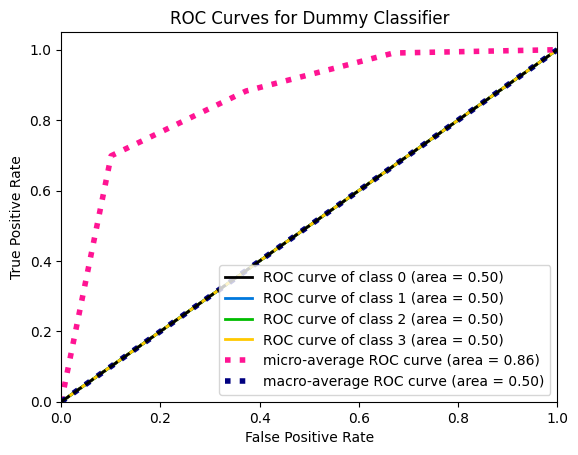

In [135]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for Dummy Classifier')
plt.show()


In [15]:
from sklearn.tree import DecisionTreeClassifier

Accuracy 0.5914115646258503
F1-score [0.74712644 0.23581758 0.20806794 0.07142857]
              precision    recall  f1-score   support

           0       0.74      0.75      0.75      1643
           1       0.23      0.24      0.24       433
           2       0.23      0.19      0.21       254
           3       0.17      0.05      0.07        22

    accuracy                           0.59      2352
   macro avg       0.34      0.31      0.32      2352
weighted avg       0.59      0.59      0.59      2352



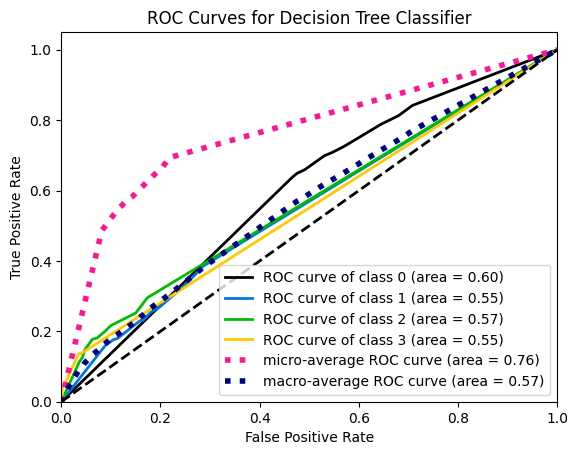

In [136]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred0 = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred0))
print('F1-score %s' % f1_score(y_test, y_pred0, average=None))
print(classification_report(y_test, y_pred0))

y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for Decision Tree Classifier')
plt.show()

In [81]:
from sklearn.neighbors import KNeighborsClassifier

Accuracy 0.6840986394557823
F1-score [0.81618799 0.13888889 0.04347826 0.        ]
              precision    recall  f1-score   support

           0       0.71      0.95      0.82      1643
           1       0.28      0.09      0.14       433
           2       0.27      0.02      0.04       254
           3       0.00      0.00      0.00        22

    accuracy                           0.68      2352
   macro avg       0.32      0.27      0.25      2352
weighted avg       0.58      0.68      0.60      2352



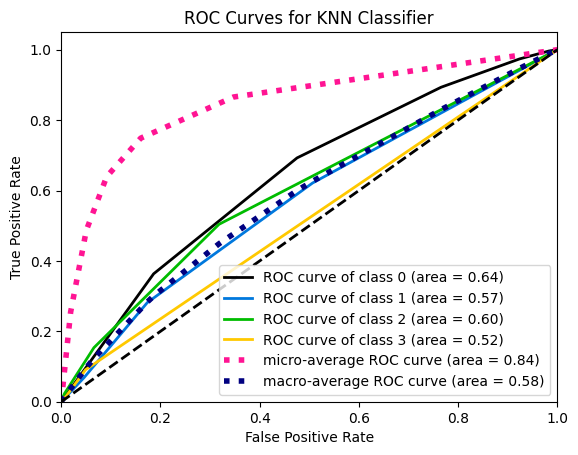

In [140]:
# fit
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

#### the following worked for the binary case but not now, ignore

In [ ]:
# storing class 3 ROC curve for successive comparisons
y_score = clf.predict_proba(X_test)
fpr0, tpr0, _ = roc_curve(y_test, y_score[:, 3])
roc_auc0 = auc(fpr0, tpr0)

ValueError: multiclass format is not supported

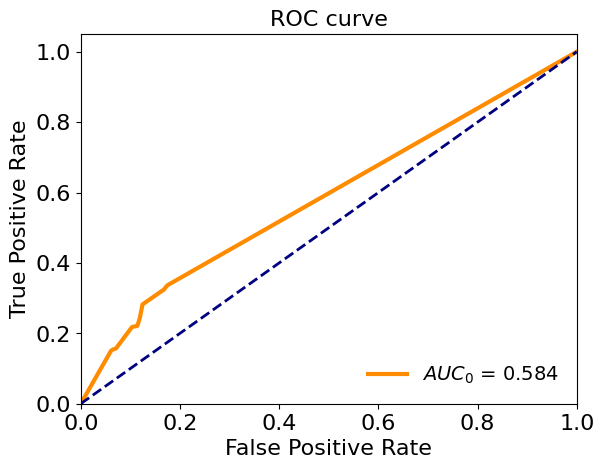

In [ ]:
# worked for the binary case but not now
plt.plot(fpr0, tpr0, color='darkorange', lw=3, label='$AUC_0$ = %.3f' % (roc_auc0))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC curve', fontsize=16)
plt.legend(loc="lower right", fontsize=14, frameon=False)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

In [ ]:
# not done
def plot_ROC_comparison(fpr, tpr):
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr0, tpr0, color='darkorange', lw=3, label='$AUC_0$ = %.3f' % (roc_auc0))
    plt.plot(fpr, tpr, color='green', lw=3, label='$AUC_1$ = %.3f' % (roc_auc))
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.title('ROC curve', fontsize=16)
    plt.legend(loc="lower right", fontsize=14, frameon=False)
    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.show()

## PCA (just for visualisation)

In [28]:
from sklearn.decomposition import PCA

In [29]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
    plt.show()

In [30]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
print(X_train.shape, X_pca.shape)

(5487, 32) (5487, 2)


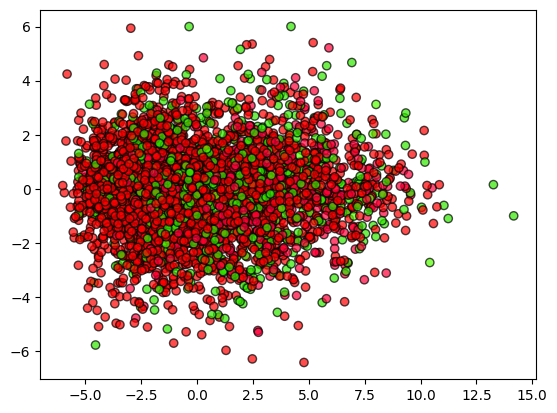

In [ ]:
plot_pca(X_pca, y_train)
# this was guidotti's code, but for us, shouldn't 4 classes be 4 colors?
# comparing the plots, seems like this is red = class 0, green = all the rest

(array([0, 1, 2, 3]), array([3833, 1011,  592,   51]))


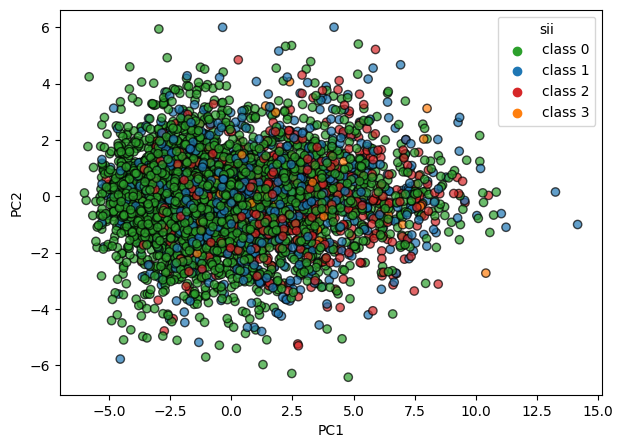

In [39]:
# confirm labels and plot with discrete colors so each class has its own color
print(np.unique(y_train, return_counts=True))

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_train.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_train):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

## Hyper-parameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

In [141]:
# DT default: gini criterion, no max depth, min_samples_split=2, min_samples_leaf=1, no class weights
param_list = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 3, 5, 10]
}

#random_search = RandomizedSearchCV(
#    DecisionTreeClassifier(),
#    param_distributions=param_list,
#    cv=RepeatedStratifiedKFold(random_state=0),
#    n_jobs=-1,
#    refit=True,
#    n_iter=200,
    #verbose=2
#)
#random_search.fit(X_train, y_train)
#clf = random_search.best_estimator_

griddt = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid=param_list,
    scoring='f1_macro',
    cv=RepeatedStratifiedKFold(random_state=0),
    n_jobs=-1,
    refit=True,
    # verbose=2
)

griddt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...andom_state=0)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [142]:
print(griddt.best_params_, griddt.best_score_)

{'max_depth': 10, 'min_samples_leaf': 1} 0.2957917077648601


In [ ]:
# try doing it for example with the random undersampled datased. problem: changes completely based on the random chosen points
griddt.fit(X_res, y_res)
print(griddt.best_params_, griddt.best_score_)

{'max_depth': 5, 'min_samples_leaf': 10} 0.3146707317073171


In [ ]:
# KNN default: 5 neighbours, minkowski distance, uniform weights

param_grid = {
    "n_neighbors": [3,5,7,11],
    "weights": ["uniform", "distance"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=RepeatedStratifiedKFold(random_state=0),
    n_jobs=-1,
    refit=True,
    # verbose=2
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...andom_state=0)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [144]:
print(grid.best_params_, grid.best_score_)

{'n_neighbors': 3, 'weights': 'distance'} 0.2826343431679701


In [111]:
grid.fit(X_res, y_res)
print(grid.best_params_, grid.best_score_)

{'n_neighbors': 11, 'weights': 'distance'} 0.2980853658536585


In [ ]:
# For imbalanced data, accuracy can be misleading. since it can look excellent even when minority classes are predicted poorly.
# Most important metrics: Macro F1-score, per-class recall (especially minority), 

In [ ]:
# OBS: using these parameters, and the default scoring (accuracy) the results are actually worse (for the minority class).
# changing the scoring to f1 macro doesn't make it much better either.
# therefore we will keep the 'default' parameters

In [ ]:
# with the following techniques, check if the recall changes the most
# the macro average f1 is not always better
# relevant: results for the minority class
# if a method is theoretically better than other, practically it will always work better: no, it depends on the dataset

In [ ]:
# “Classifier hyperparameters were fixed across all balancing techniques to ensure fair comparison and isolate the effect of the resampling methods.”

# Undersampling

In [33]:
#!pip install imblearn
#!pip install imbalanced-learn # hidden inside the first one but it is needed as well

In [34]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

### RandomUnderSampler

In [145]:
# make al classes have the same number of records as the minority class (51). NO balancing the test set (it is truthful to reality)!
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 51, 1: 51, 2: 51, 3: 51})


In [146]:
pca = PCA(n_components=2)
pca.fit(X_train) # PCA learns the principal directions from the original training distribution.
X_pca = pca.transform(X_res) # The under-sampled data are projected onto those directions.
#plot_pca(X_pca, y_res)


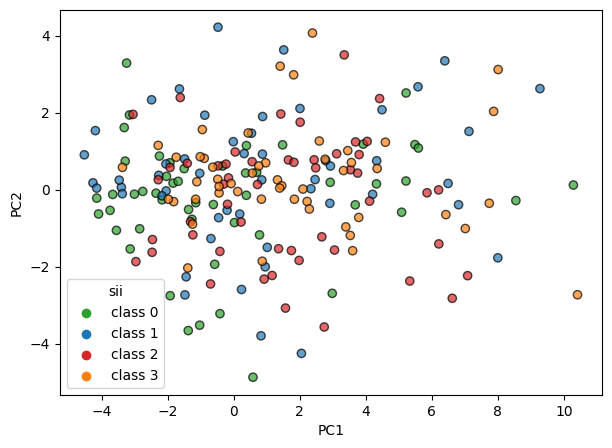

In [147]:
# NO NEED reporting it on the report

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_res.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_res):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

Accuracy 0.3201530612244898
F1-score [0.45922747 0.24375    0.18685832 0.04545455]
              precision    recall  f1-score   support

           0       0.78      0.33      0.46      1643
           1       0.22      0.27      0.24       433
           2       0.13      0.36      0.19       254
           3       0.02      0.45      0.05        22

    accuracy                           0.32      2352
   macro avg       0.29      0.35      0.23      2352
weighted avg       0.60      0.32      0.39      2352



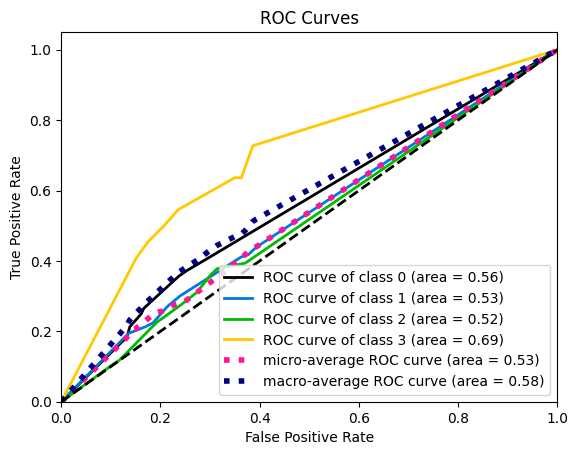

In [148]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

Accuracy 0.3231292517006803
F1-score [0.51053678 0.18039216 0.1426025  0.02085747]
              precision    recall  f1-score   support

           0       0.74      0.39      0.51      1643
           1       0.21      0.16      0.18       433
           2       0.13      0.16      0.14       254
           3       0.01      0.41      0.02        22

    accuracy                           0.32      2352
   macro avg       0.27      0.28      0.21      2352
weighted avg       0.57      0.32      0.41      2352



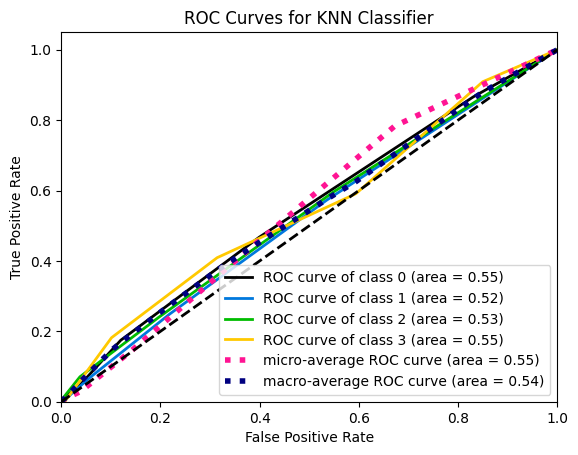

In [149]:
# fit KNN
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

### CondensedNearestNeighbour

In [46]:
import warnings
warnings.simplefilter("ignore")

In [150]:
cnn = CondensedNearestNeighbour(random_state=42, n_jobs=10)
X_res, y_res = cnn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 399, 1: 278, 2: 228, 3: 51})


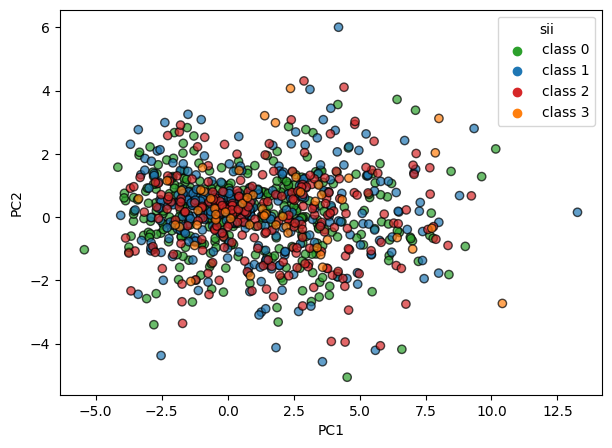

In [151]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
#plot_pca(X_pca, y_res)

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_res.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_res):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

Accuracy 0.45408163265306123
F1-score [0.60944206 0.26055705 0.19047619 0.03333333]
              precision    recall  f1-score   support

           0       0.74      0.52      0.61      1643
           1       0.21      0.33      0.26       433
           2       0.15      0.28      0.19       254
           3       0.03      0.05      0.03        22

    accuracy                           0.45      2352
   macro avg       0.28      0.29      0.27      2352
weighted avg       0.57      0.45      0.49      2352



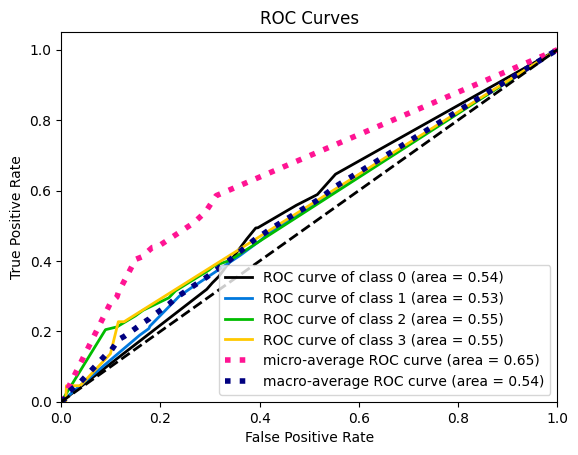

In [152]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

Accuracy 0.5956632653061225
F1-score [0.75167785 0.21860465 0.09669211 0.        ]
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      1643
           1       0.22      0.22      0.22       433
           2       0.14      0.07      0.10       254
           3       0.00      0.00      0.00        22

    accuracy                           0.60      2352
   macro avg       0.27      0.27      0.27      2352
weighted avg       0.56      0.60      0.58      2352



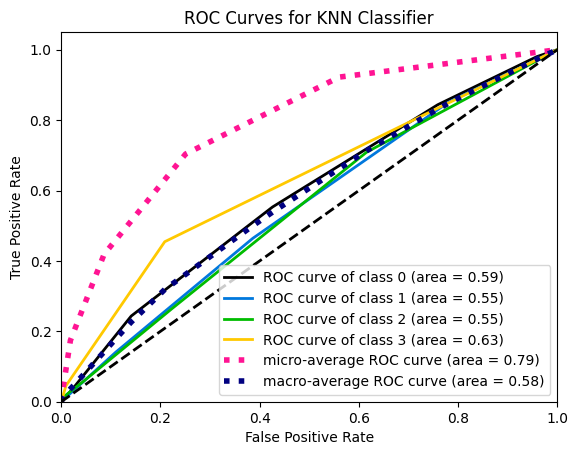

In [153]:
# fit KNN
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

### Tomek Links

In [154]:
tl = TomekLinks()
X_res, y_res = tl.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 3626, 1: 831, 2: 495, 3: 51})


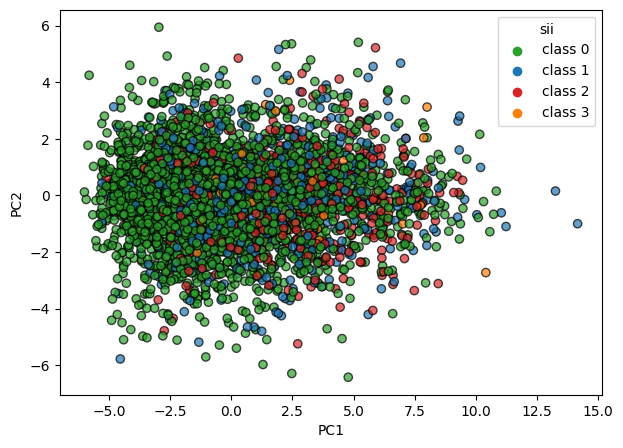

In [52]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
#plot_pca(X_pca, y_res)

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_res.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_res):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

Accuracy 0.6215986394557823
F1-score [0.76747587 0.2540074  0.21266968 0.        ]
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      1643
           1       0.27      0.24      0.25       433
           2       0.25      0.19      0.21       254
           3       0.00      0.00      0.00        22

    accuracy                           0.62      2352
   macro avg       0.32      0.31      0.31      2352
weighted avg       0.59      0.62      0.61      2352



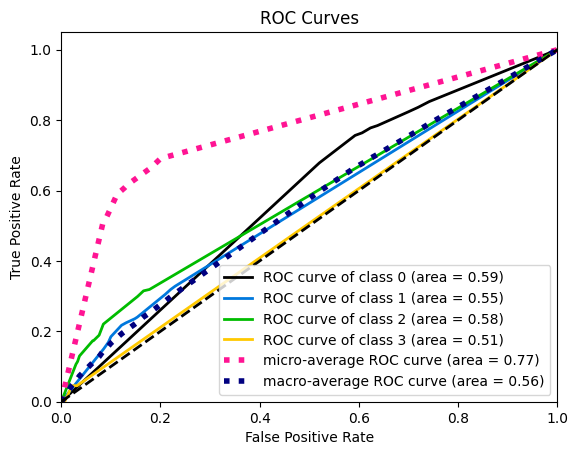

In [155]:
# fit 
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

Accuracy 0.6845238095238095
F1-score [0.81698162 0.1025641  0.02930403 0.        ]
              precision    recall  f1-score   support

           0       0.71      0.96      0.82      1643
           1       0.25      0.06      0.10       433
           2       0.21      0.02      0.03       254
           3       0.00      0.00      0.00        22

    accuracy                           0.68      2352
   macro avg       0.29      0.26      0.24      2352
weighted avg       0.56      0.68      0.59      2352



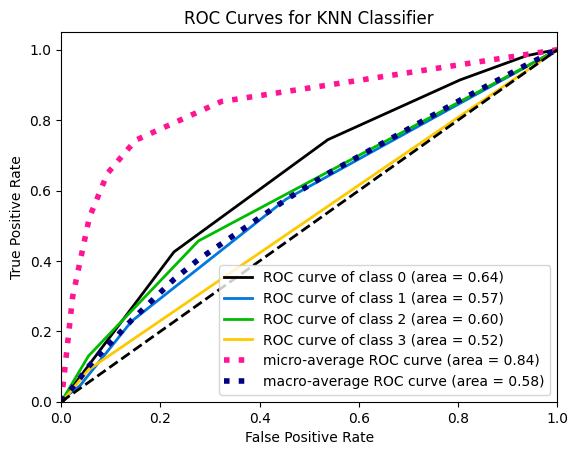

In [158]:
# fit KNN
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

### Edited Nearest Neighbors

In [159]:
enn = EditedNearestNeighbours()
X_res, y_res = enn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 1967, 3: 51, 1: 7, 2: 4})


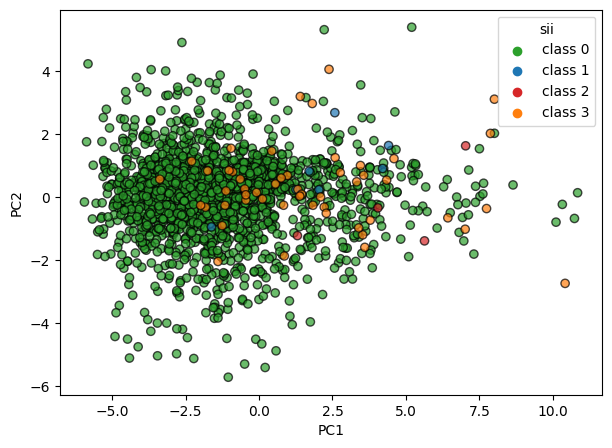

In [160]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
#plot_pca(X_pca, y_res)

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_res.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_res):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

Accuracy 0.6679421768707483
F1-score [0.8125163  0.02637363 0.02962963 0.04166667]
              precision    recall  f1-score   support

           0       0.71      0.95      0.81      1643
           1       0.27      0.01      0.03       433
           2       0.25      0.02      0.03       254
           3       0.02      0.14      0.04        22

    accuracy                           0.67      2352
   macro avg       0.31      0.28      0.23      2352
weighted avg       0.57      0.67      0.58      2352



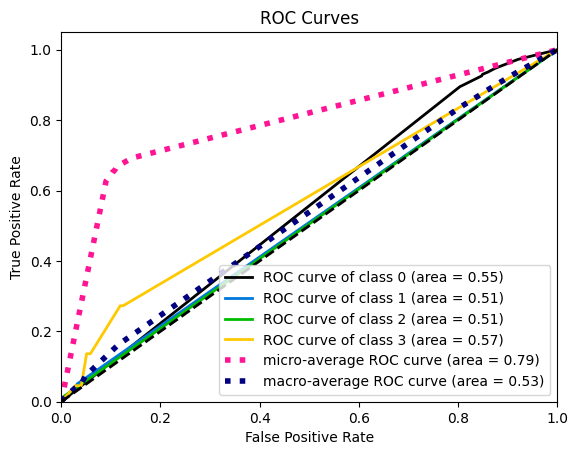

In [161]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

Accuracy 0.6981292517006803
F1-score [0.82223335 0.         0.         0.        ]
              precision    recall  f1-score   support

           0       0.70      1.00      0.82      1643
           1       0.00      0.00      0.00       433
           2       0.00      0.00      0.00       254
           3       0.00      0.00      0.00        22

    accuracy                           0.70      2352
   macro avg       0.17      0.25      0.21      2352
weighted avg       0.49      0.70      0.57      2352



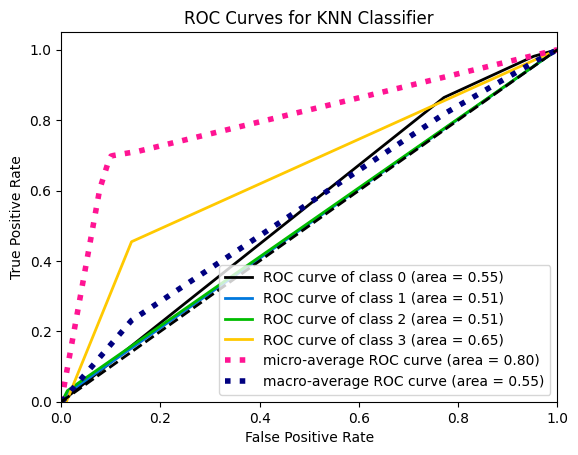

In [162]:
# fit KNN
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

### Cluster Centroids

In [57]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids

In [175]:
cc = ClusterCentroids(
    estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42
)
#X_res, y_res = cc.fit_resample(X, y)
#print('Resampled dataset shape %s' % Counter(y_res))

# he's using the whole dataset X y. gives better results than just train but is it correct? isn't it data leakage? 
X_res, y_res = cc.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({0: 51, 1: 51, 2: 51, 3: 51})


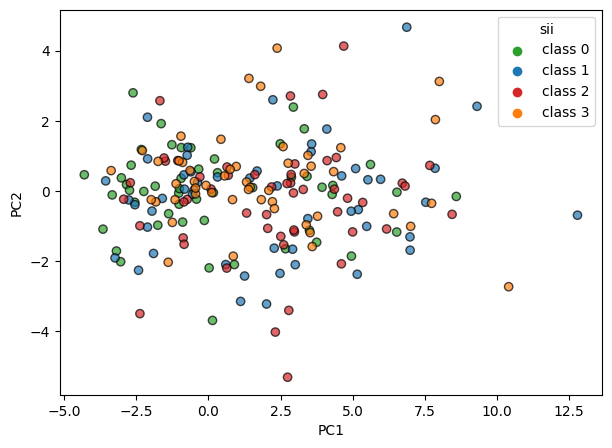

In [74]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
#plot_pca(X_pca, y_res)

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_res.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_res):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

Accuracy 0.04039115646258504
F1-score [0.         0.03397028 0.16985646 0.01824401]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1643
           1       0.21      0.02      0.03       433
           2       0.12      0.28      0.17       254
           3       0.01      0.73      0.02        22

    accuracy                           0.04      2352
   macro avg       0.09      0.26      0.06      2352
weighted avg       0.05      0.04      0.02      2352



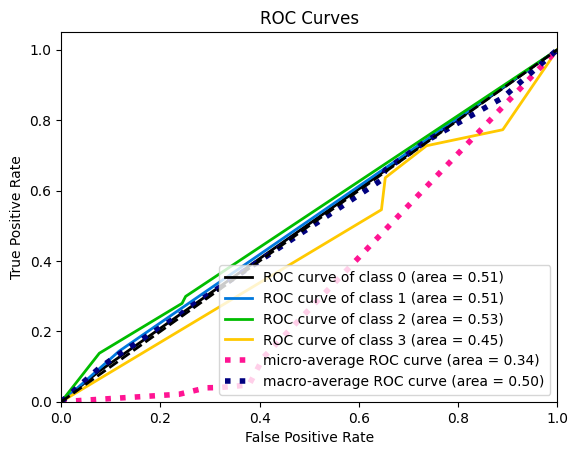

In [164]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

Accuracy 0.5535714285714286
F1-score [0.72067039 0.24519231 0.16306954 0.04291845]
              precision    recall  f1-score   support

           0       0.74      0.71      0.72      1643
           1       0.26      0.24      0.25       433
           2       0.21      0.13      0.16       254
           3       0.02      0.23      0.04        22

    accuracy                           0.55      2352
   macro avg       0.31      0.33      0.29      2352
weighted avg       0.58      0.55      0.57      2352



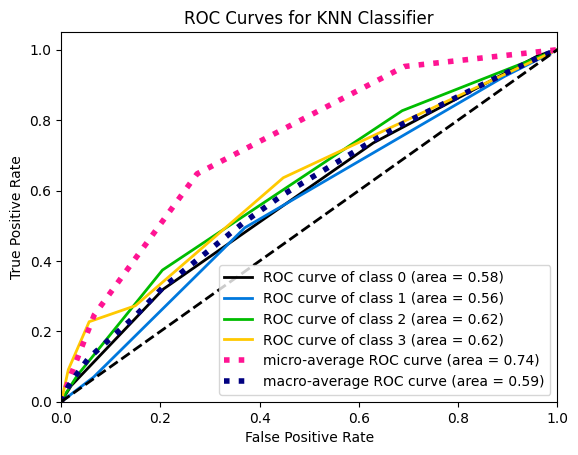

In [165]:
# fit KNN
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

# Oversampling

In [64]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

### RandomOverSampler

In [166]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 3833, 0: 3833, 2: 3833, 3: 3833})


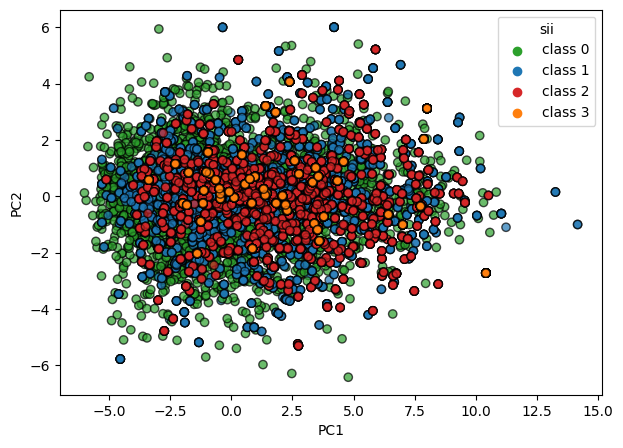

In [167]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
#plot_pca(X_pca, y_res)

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_res.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_res):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

Accuracy 0.5544217687074829
F1-score [0.71378764 0.24511931 0.22338569 0.03703704]
              precision    recall  f1-score   support

           0       0.74      0.69      0.71      1643
           1       0.23      0.26      0.25       433
           2       0.20      0.25      0.22       254
           3       0.03      0.05      0.04        22

    accuracy                           0.55      2352
   macro avg       0.30      0.31      0.30      2352
weighted avg       0.58      0.55      0.57      2352



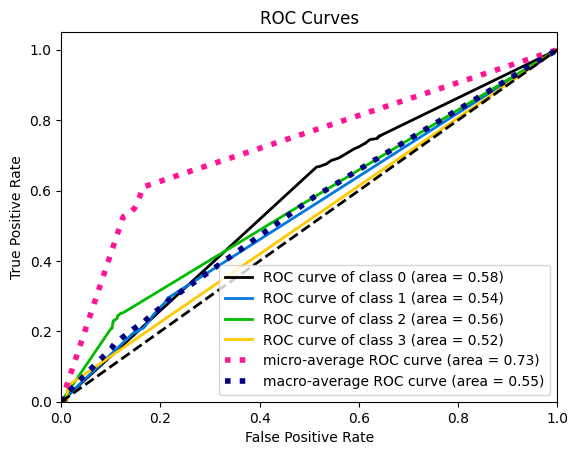

In [168]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict 
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

Accuracy 0.4817176870748299
F1-score [0.64468085 0.27574171 0.19877676 0.02380952]
              precision    recall  f1-score   support

           0       0.77      0.55      0.64      1643
           1       0.22      0.36      0.28       433
           2       0.16      0.26      0.20       254
           3       0.02      0.05      0.02        22

    accuracy                           0.48      2352
   macro avg       0.29      0.30      0.29      2352
weighted avg       0.60      0.48      0.52      2352



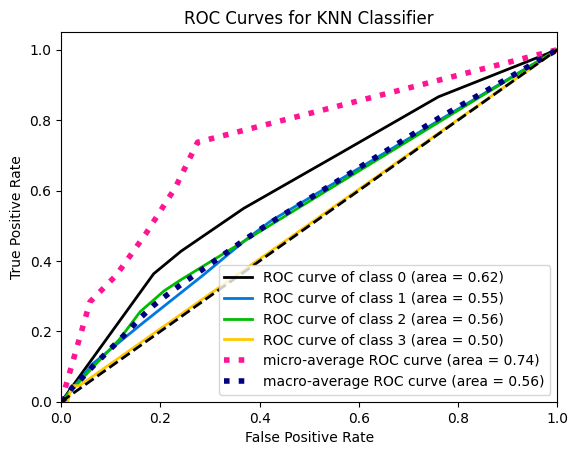

In [169]:
# fit KNN
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

### SMOTE

In [170]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 3833, 0: 3833, 2: 3833, 3: 3833})


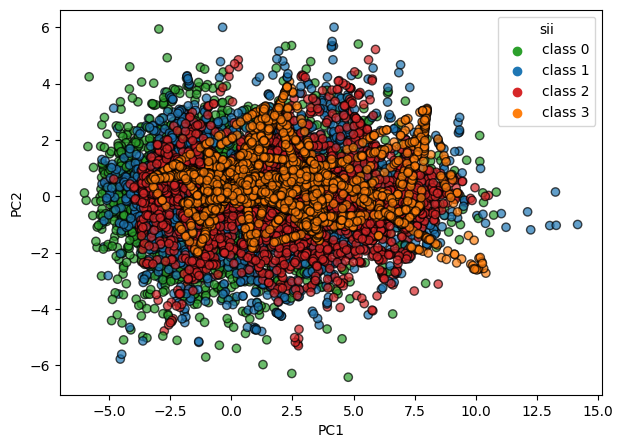

In [171]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
#plot_pca(X_pca, y_res)

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_res.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_res):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

Accuracy 0.5344387755102041
F1-score [0.70006423 0.23966942 0.1740675  0.06779661]
              precision    recall  f1-score   support

           0       0.74      0.66      0.70      1643
           1       0.22      0.27      0.24       433
           2       0.16      0.19      0.17       254
           3       0.05      0.09      0.07        22

    accuracy                           0.53      2352
   macro avg       0.29      0.30      0.30      2352
weighted avg       0.58      0.53      0.55      2352



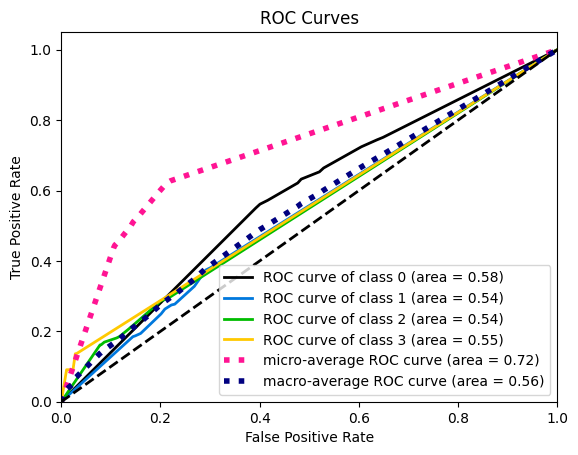

In [172]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

Accuracy 0.40901360544217685
F1-score [0.56372166 0.26755853 0.20838972 0.03791469]
              precision    recall  f1-score   support

           0       0.79      0.44      0.56      1643
           1       0.21      0.37      0.27       433
           2       0.16      0.30      0.21       254
           3       0.02      0.18      0.04        22

    accuracy                           0.41      2352
   macro avg       0.29      0.32      0.27      2352
weighted avg       0.61      0.41      0.47      2352



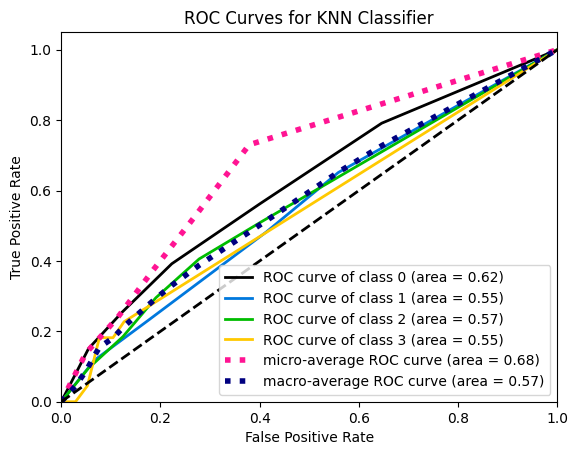

In [173]:
# fit KNN
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

### ADASYN

In [176]:
ada = ADASYN(random_state=42)
#X_res, y_res = ada.fit_resample(X, y)
#print('Resampled dataset shape %s' % Counter(y_res))
# once again he's using X and y...

X_res, y_res = ada.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 3833, 3: 3831, 2: 3728, 1: 3715})


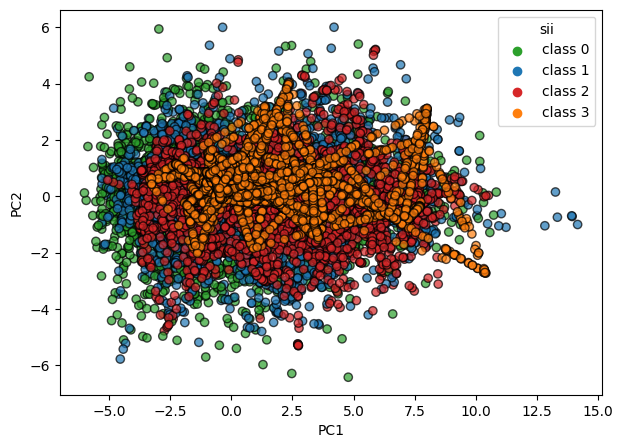

In [177]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
#plot_pca(X_pca, y_res)

colors_map = np.array(['tab:green', 'tab:blue', 'tab:red', 'tab:orange'])

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_map[y_res.values], edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')

# legend proxies
for i in np.unique(y_res):
    plt.scatter([], [], color=colors_map[i], label=f'class {i}')
plt.legend(title='sii', loc='best')
plt.show()

Accuracy 0.5569727891156463
F1-score [0.72376738 0.24494143 0.18115942 0.        ]
              precision    recall  f1-score   support

           0       0.75      0.70      0.72      1643
           1       0.23      0.27      0.24       433
           2       0.17      0.20      0.18       254
           3       0.00      0.00      0.00        22

    accuracy                           0.56      2352
   macro avg       0.29      0.29      0.29      2352
weighted avg       0.59      0.56      0.57      2352



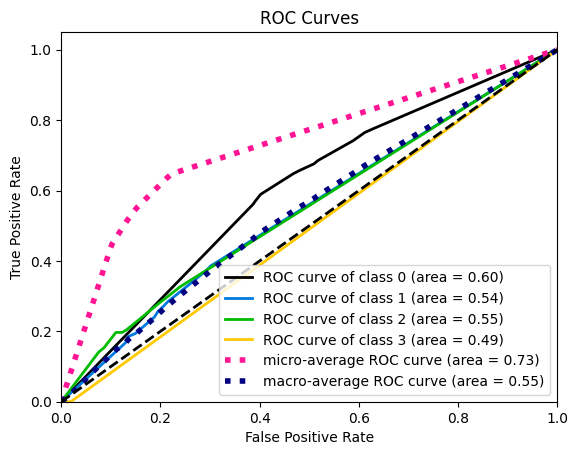

In [178]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

Accuracy 0.40816326530612246
F1-score [0.55934195 0.27722772 0.20754717 0.01015228]
              precision    recall  f1-score   support

           0       0.78      0.43      0.56      1643
           1       0.22      0.39      0.28       433
           2       0.16      0.30      0.21       254
           3       0.01      0.05      0.01        22

    accuracy                           0.41      2352
   macro avg       0.29      0.29      0.26      2352
weighted avg       0.60      0.41      0.46      2352



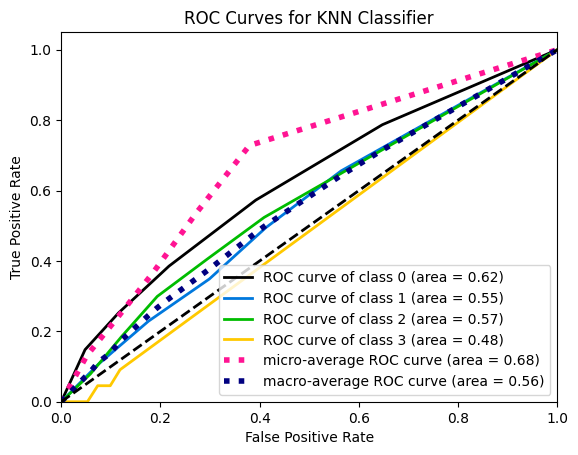

In [179]:
# fit KNN
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.title('ROC Curves for KNN Classifier')
plt.show()

# Balancing at the Algorithm Level

### Class Weight

Accuracy 0.5119047619047619
F1-score [0.67136623 0.26145038 0.21746293 0.02857143]
              precision    recall  f1-score   support

           0       0.75      0.61      0.67      1643
           1       0.22      0.32      0.26       433
           2       0.19      0.26      0.22       254
           3       0.02      0.05      0.03        22

    accuracy                           0.51      2352
   macro avg       0.29      0.31      0.29      2352
weighted avg       0.58      0.51      0.54      2352



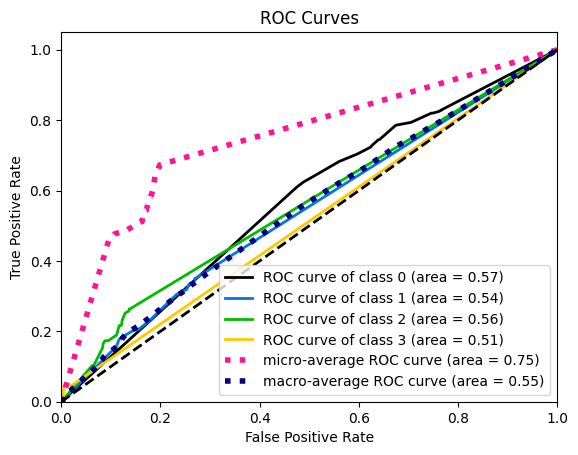

In [182]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, class_weight={0:1, 1:5, 2:10, 3:20}, random_state=42)
clf.fit(X_train, y_train)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

### Decision Threshold (NOT done)

Accuracy 0.6696428571428571
F1-score [0.80191693 0.20535714 0.         0.        ]
              precision    recall  f1-score   support

           0       0.71      0.92      0.80      1643
           1       0.29      0.16      0.21       433
           2       0.00      0.00      0.00       254
           3       0.00      0.00      0.00        22

    accuracy                           0.67      2352
   macro avg       0.25      0.27      0.25      2352
weighted avg       0.55      0.67      0.60      2352



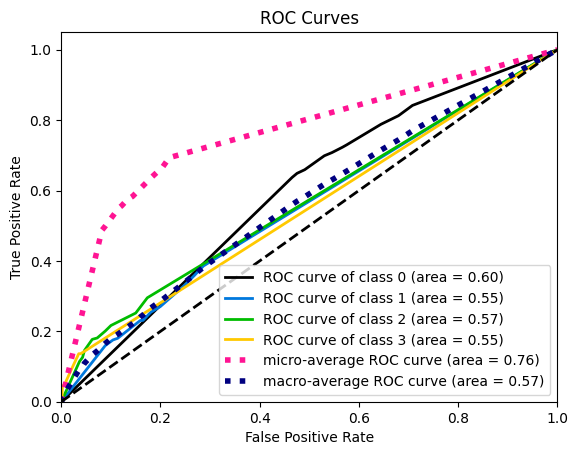

In [ ]:
# not done, the code should be changed to work for multiple classes
# very naïve method

def adjusted_predict(X, thr=0.5):
    y_score = clf.predict_proba(X_test)[:, 1] # written by guidotti, but this ignores the parameter X and always uses X_test! change it for X
    return np.array([1 if y > thr else 0 for y in y_score])

# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

# predict
y_pred = adjusted_predict(X_test, thr=0.9)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
#fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
#plot_ROC_comparison(fpr, tpr)

# Meta-Cost Sensitive Classifier (NOT done)

In [ ]:
# to be able to specify cost matrix. not mandatory.

In [67]:
# Credits to Simone Di Luna
import sys
import joblib
import six
import sklearn.ensemble._base
sys.modules['sklearn.externals.joblib'] = joblib
sys.modules['sklearn.externals.six'] = six
sys.modules['sklearn.externals.six.moves'] = six.moves
sys.modules['sklearn.ensemble.base'] = sklearn.ensemble._base

In [68]:
# !pip install costcla

In [69]:
from costcla.models import CostSensitiveDecisionTreeClassifier
from costcla.metrics import savings_score

cost_mat : array-like of shape = [n_samples, 4]

Cost matrix of the classification problem Where the columns represents the costs of: false positives, false negatives, true positives and true negatives, for each example.

In [70]:
cost = [1, 10, 0, 0]
cost_mat = np.array([cost] * len(X_train))
cost_mat.shape

(162, 4)

In [71]:
cost_mat

array([[ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],
       [ 1, 10,  0,  0],


In [72]:
np.float = float # workaround necessary for np versions >= 1.20.0
clf = CostSensitiveDecisionTreeClassifier()
clf.fit(X_train, y_train, cost_mat)

CostSensitiveDecisionTreeClassifier()

Accuracy 0.9428571428571428
F1-score [0.96923077 0.6       ]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        64
           1       0.75      0.50      0.60         6

    accuracy                           0.94        70
   macro avg       0.85      0.74      0.78        70
weighted avg       0.94      0.94      0.94        70



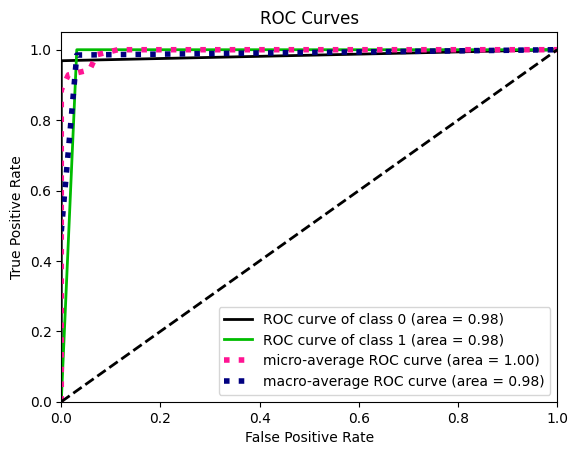

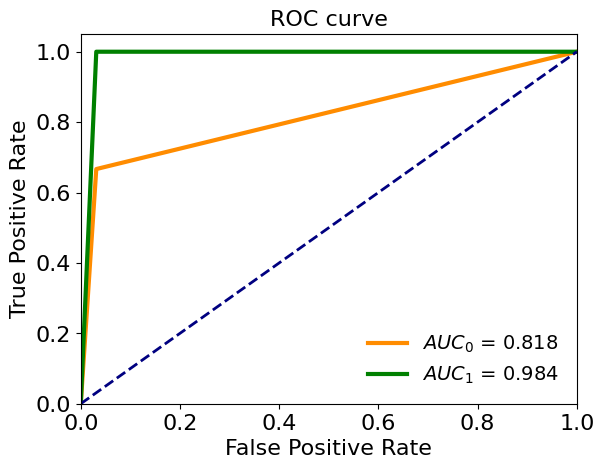

In [73]:
# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
plot_ROC_comparison(fpr, tpr)

In [74]:
cost_mat_test = np.array([cost] * len(X_test))
print(savings_score(y_test, y_pred, cost_mat_test))
print(savings_score(y_test, y_pred0, cost_mat_test))

0.4833333333333333
0.6333333333333333


# Corrected Decision Tree (NOT to be done)

In [ ]:
#sklearn dt have a problem: sometimes do useless splits. his function prune_duplicate_leaves just changes the visualization, doesn't affect the performance

In [75]:
from sklearn.tree._tree import TREE_LEAF

In [76]:
def is_leaf(inner_tree, index):
    # Check whether node is leaf node
    return (inner_tree.children_left[index] == TREE_LEAF and
            inner_tree.children_right[index] == TREE_LEAF)


def prune_index(inner_tree, decisions, index=0):
    # Start pruning from the bottom - if we start from the top, we might miss
    # nodes that become leaves during pruning.
    # Do not use this directly - use prune_duplicate_leaves instead.
    if not is_leaf(inner_tree, inner_tree.children_left[index]):
        prune_index(inner_tree, decisions, inner_tree.children_left[index])
    if not is_leaf(inner_tree, inner_tree.children_right[index]):
        prune_index(inner_tree, decisions, inner_tree.children_right[index])

    # Prune children if both children are leaves now and make the same decision:
    if (is_leaf(inner_tree, inner_tree.children_left[index]) and
        is_leaf(inner_tree, inner_tree.children_right[index]) and
        (decisions[index] == decisions[inner_tree.children_left[index]]) and
        (decisions[index] == decisions[inner_tree.children_right[index]])):
        # turn node into a leaf by "unlinking" its children
        inner_tree.children_left[index] = TREE_LEAF
        inner_tree.children_right[index] = TREE_LEAF
        # print("Pruned {}".format(index))


def prune_duplicate_leaves(dt):
    # Remove leaves if both
    decisions = dt.tree_.value.argmax(axis=2).flatten().tolist()  # Decision for each node
    prune_index(dt.tree_, decisions)

In [77]:
import numpy as np
from sklearn.datasets import load_iris

frame = load_iris(as_frame=True)
df = frame['data']
X = df.values
y = np.array(frame['target'])

In [78]:
from sklearn.tree import DecisionTreeClassifier

In [79]:
from sklearn import tree
import matplotlib.pyplot as plt

In [80]:
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=3)

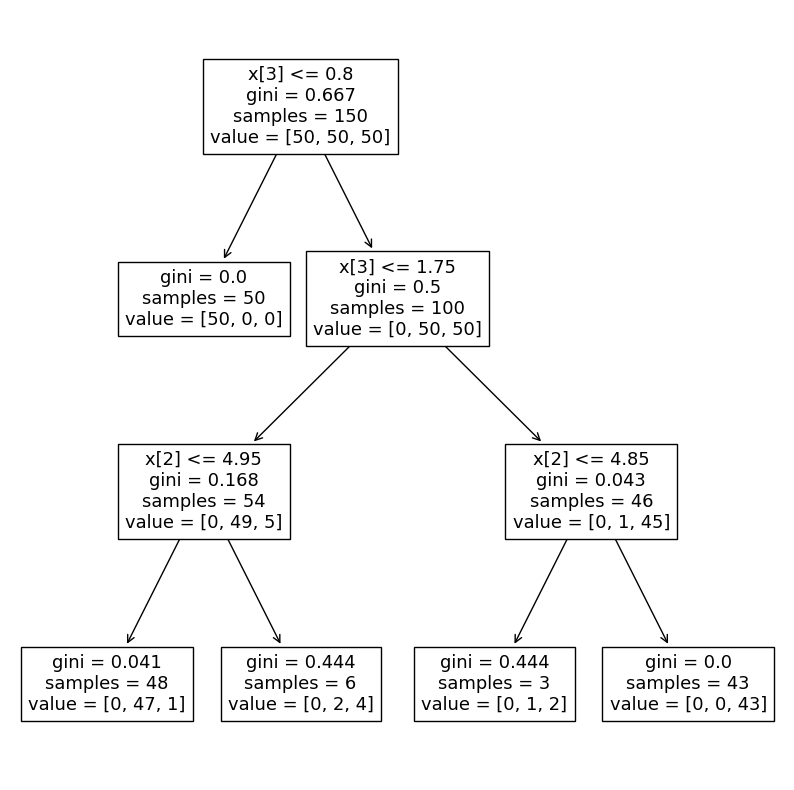

In [81]:
plt.figure(figsize=(10,10))
tree.plot_tree(clf)
plt.show()

In [82]:
prune_duplicate_leaves(clf)

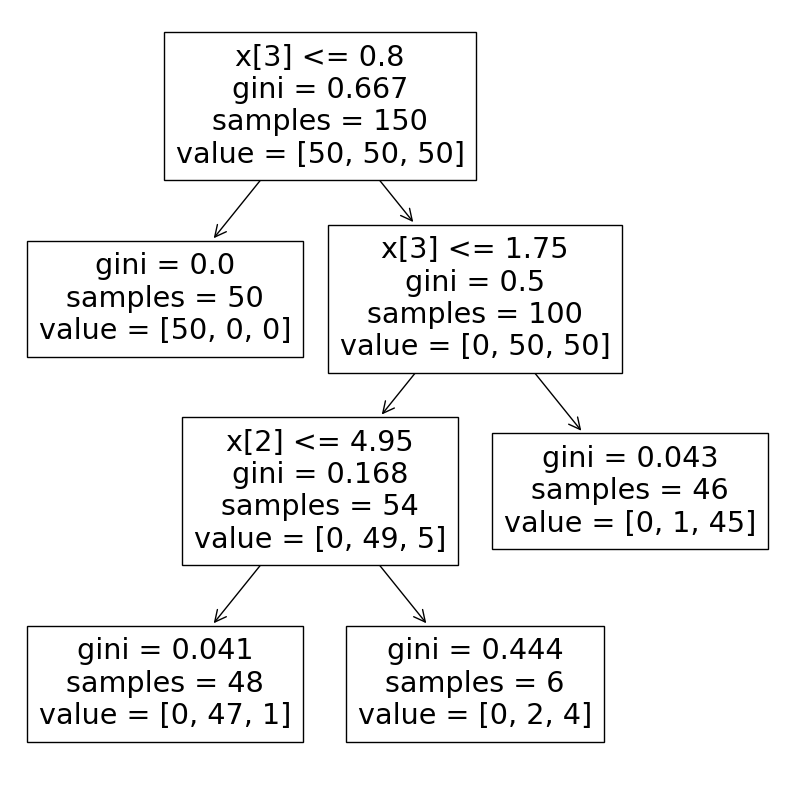

In [83]:
plt.figure(figsize=(10,10))
tree.plot_tree(clf)
plt.show()